In [3]:
def _masked_softmax_over_layers(S, keep_mask, *, temperature=1.0, eps=1e-12):
    """
    Softmax over the layer axis.

    S:         [N, L, T]
    keep_mask: [N, L, T] bool

    Returns:
        P: [N, L, T], where P[n, :, t] sums to 1 only if at least one layer survived.
           If no layer survived, P[n, :, t] is all zeros.
    """
    S = np.asarray(S, dtype=float)

    if temperature <= 0:
        raise ValueError("temperature must be > 0")

    X = S / temperature

    # Critical: masked-out entries must not receive softmax mass.
    X = np.where(keep_mask & np.isfinite(X), X, -np.inf)

    # Stable softmax over layer axis.
    valid_any = np.any(np.isfinite(X), axis=1, keepdims=True)  # [N, 1, T]

    max_x = np.max(X, axis=1, keepdims=True)
    max_x = np.where(valid_any, max_x, 0.0)

    exp_x = np.exp(X - max_x)
    exp_x = np.where(np.isfinite(X), exp_x, 0.0)

    denom = exp_x.sum(axis=1, keepdims=True)

    P = np.divide(
        exp_x,
        denom,
        out=np.zeros_like(exp_x),
        where=denom > eps,
    )

    return P



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import to_rgba
def _masked_softmax_over_layers(S, keep_mask, *, temperature=1.0, eps=1e-12):
    """
    Softmax over the layer axis.

    S:         [N, L, T]
    keep_mask: [N, L, T] bool

    Returns:
        P: [N, L, T], where P[n, :, t] sums to 1 only if at least one layer survived.
           If no layer survived, P[n, :, t] is all zeros.
    """
    S = np.asarray(S, dtype=float)

    if temperature <= 0:
        raise ValueError("temperature must be > 0")

    X = S / temperature

    # Critical: masked-out entries must not receive softmax mass.
    X = np.where(keep_mask & np.isfinite(X), X, -np.inf)

    # Stable softmax over layer axis.
    valid_any = np.any(np.isfinite(X), axis=1, keepdims=True)  # [N, 1, T]

    max_x = np.max(X, axis=1, keepdims=True)
    max_x = np.where(valid_any, max_x, 0.0)

    exp_x = np.exp(X - max_x)
    exp_x = np.where(np.isfinite(X), exp_x, 0.0)

    denom = exp_x.sum(axis=1, keepdims=True)

    P = np.divide(
        exp_x,
        denom,
        out=np.zeros_like(exp_x),
        where=denom > eps,
    )

    return P



def data_source(args):
    data = np.load(
        f"{args[2]}/evolution_patterns_e{args[0]}_l{args[1]}.npz"
    )
    stats = data["concepts"]
    S = data["cor_res"]
    epochs = data["epochs"]
    return S, stats, epochs


def _weighted_median_1d(x, w, eps=1e-12):
    """
    Weighted median of x under nonnegative weights w.
    """
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)

    valid = np.isfinite(x) & np.isfinite(w) & (w > eps)
    if valid.sum() == 0:
        return np.nan

    x = x[valid]
    w = w[valid]

    order = np.argsort(x)
    x = x[order]
    w = w[order]

    cdf = np.cumsum(w)
    cutoff = 0.5 * cdf[-1]

    return float(x[np.searchsorted(cdf, cutoff)])


def _find_first_sustained_run(mask, start=0, k=1):
    """
    Return first index of a sustained True run of length k, or None.
    """
    mask = np.asarray(mask, dtype=bool)
    k = max(1, int(k))

    for i in range(start, len(mask) - k + 1):
        if mask[i:i + k].all():
            return i

    return None


def _has_later_sustained_run(mask, start, k=1):
    return _find_first_sustained_run(mask, start=start, k=k) is not None


def _active_mask_from_threshold(
    epoch_signal,
    threshold,
    *,
    onset_k=3,
    disappearance_k=3,
    active_mode="threshold_after_emergence",
):
    """
    Build concept x epoch active masks.

    active_mode:
        "threshold":
            all epochs above threshold.

        "threshold_after_emergence":
            above-threshold epochs only after sustained emergence.

        "lifetime":
            all epochs between sustained emergence and final sustained disappearance.
            This can include below-threshold gaps.

        "lifetime_and_threshold":
            epochs between emergence and disappearance, but only if above threshold.
    """
    epoch_signal = np.asarray(epoch_signal, dtype=float)
    N, T = epoch_signal.shape

    if threshold is None:
        theta = 0.5 * np.nanmax(epoch_signal, axis=1)
    elif np.isscalar(threshold):
        theta = np.full(N, float(threshold))
    else:
        theta = np.asarray(threshold, dtype=float)
        if theta.shape != (N,):
            raise ValueError(f"threshold array must have shape ({N},), got {theta.shape}")

    above = epoch_signal > theta[:, None]
    active = np.zeros_like(above, dtype=bool)

    emergence_idx = np.full(N, -1, dtype=int)
    disappearance_idx = np.full(N, -1, dtype=int)

    for n in range(N):
        a = above[n]

        if active_mode == "threshold":
            active[n] = a
            hits = np.where(a)[0]
            if hits.size:
                emergence_idx[n] = int(hits[0])
            continue

        e = _find_first_sustained_run(a, start=0, k=onset_k)
        if e is None:
            continue

        emergence_idx[n] = e

        # Find final disappearance: first sustained below-threshold run after
        # emergence with no later sustained re-emergence.
        d = None
        search_start = e + onset_k

        below = ~a
        while search_start < T:
            cand = _find_first_sustained_run(
                below,
                start=search_start,
                k=disappearance_k,
            )

            if cand is None:
                break

            later_start = cand + disappearance_k
            if not _has_later_sustained_run(a, start=later_start, k=onset_k):
                d = cand
                break

            search_start = later_start

        if d is not None:
            disappearance_idx[n] = d
            lifetime = np.zeros(T, dtype=bool)
            lifetime[e:d] = True
        else:
            lifetime = np.zeros(T, dtype=bool)
            lifetime[e:] = True

        if active_mode == "threshold_after_emergence":
            active[n] = a & lifetime
        elif active_mode == "lifetime":
            active[n] = lifetime
        elif active_mode == "lifetime_and_threshold":
            active[n] = lifetime & a
        else:
            raise ValueError(
                "active_mode must be one of: "
                "'threshold', 'threshold_after_emergence', "
                "'lifetime', 'lifetime_and_threshold'"
            )

    return active, theta, emergence_idx, disappearance_idx

def _compute_filtered_softmax_layer_trajectories(
    S,
    *,
    epochs,
    reference_epoch,
    reference_layer,
    threshold=None,
    layer_values=None,
    center_method="com",
    onset_k=3,
    disappearance_k=3,
    active_mode="threshold_after_emergence",
    softmax_temperature=1.0,
    tau_factor=0.5,
    eps=1e-12,
):
    """
    Compute per-concept layer trajectories after:

    1. taking positive similarities,
    2. estimating a per-concept threshold from the strongest non-self similarity,
    3. filtering similarities below that threshold,
    4. applying softmax over layers for each concept and epoch,
    5. computing COM or weighted median over layers.

    S shape: [N, L, T]
    """
    S = np.asarray(S, dtype=float)

    if S.ndim != 3:
        raise ValueError(f"S must have shape [N, L, T], got {S.shape}")

    N, L, T = S.shape

    epochs = np.asarray(epochs)
    if epochs.shape != (T,):
        raise ValueError(f"epochs must have shape ({T},), got {epochs.shape}")

    ref_epoch_indices = np.flatnonzero(epochs == reference_epoch)
    if ref_epoch_indices.size != 1:
        raise ValueError(
            f"reference_epoch={reference_epoch} must appear exactly once in epochs, "
            f"found {ref_epoch_indices.size} matches."
        )

    reference_epoch_index = int(ref_epoch_indices[0])

    if not (0 <= reference_layer < L):
        raise ValueError(f"reference_layer must be in [0, {L - 1}], got {reference_layer}")

    if layer_values is None:
        layer_values = np.arange(L, dtype=float)
    else:
        layer_values = np.asarray(layer_values, dtype=float)
        if layer_values.shape != (L,):
            raise ValueError(f"layer_values must have shape ({L},), got {layer_values.shape}")

    # Positive similarities only.
    W_raw = np.maximum(S, 0.0)  # [N, L, T]

    # Estimate threshold from the strongest non-self similarity.
    # This is safer than subtracting 1, because it explicitly excludes the
    # reference location.
    W_for_tau = W_raw.copy()
    W_for_tau[:, reference_layer, reference_epoch_index] = -np.inf

    second_peak = np.nanmax(W_for_tau, axis=(1, 2))  # [N]

    # If a concept has no valid non-self similarity, tau becomes +inf,
    # meaning nothing survives except possibly manually handled cases.
    second_peak = np.where(np.isfinite(second_peak), second_peak, np.inf)

    taus = tau_factor * second_peak  # [N]

    # Keep only similarities above the per-concept threshold.
    keep = W_raw > taus[:, None, None]  # [N, L, T]

    # Apply masked softmax over layers.
    P = _masked_softmax_over_layers(
        W_raw,
        keep,
        temperature=softmax_temperature,
        eps=eps,
    )  # [N, L, T]

    # Raw filtered signal for deciding whether the concept is active.
    # Do not use P for activity, because softmax normalizes surviving epochs to sum 1.
    W_filtered = np.where(keep, W_raw, 0.0)
    epoch_signal = W_filtered.mean(axis=1)  # [N, T]

    active, theta, emergence_idx, disappearance_idx = _active_mask_from_threshold(
        epoch_signal,
        threshold,
        onset_k=onset_k,
        disappearance_k=disappearance_k,
        active_mode=active_mode,
    )

    prob_mass_t = P.sum(axis=1)  # [N, T], either 1 or 0

    center = np.full((N, T), np.nan, dtype=float)
    width = np.full((N, T), np.nan, dtype=float)

    if center_method.lower() in {"com", "mean", "center_of_mass"}:
        center_raw = (P * layer_values[None, :, None]).sum(axis=1)

        center[prob_mass_t > eps] = center_raw[prob_mass_t > eps]

    elif center_method.lower() in {"median", "weighted_median"}:
        for n in range(N):
            for t in range(T):
                if prob_mass_t[n, t] > eps:
                    center[n, t] = _weighted_median_1d(
                        layer_values,
                        P[n, :, t],
                        eps=eps,
                    )

    else:
        raise ValueError("center_method must be 'com' or 'median'.")

    # Layer width under the softmax distribution.
    for n in range(N):
        for t in range(T):
            if prob_mass_t[n, t] <= eps or not np.isfinite(center[n, t]):
                continue

            centered = layer_values - center[n, t]
            width[n, t] = np.sqrt(np.sum(P[n, :, t] * centered**2))

    # Keep trajectory only in active area.
    center_active = center.copy()
    width_active = width.copy()

    center_active[~active] = np.nan
    width_active[~active] = np.nan

    return {
        "center": center_active,
        "width": width_active,
        "active_mask": active,
        "theta": theta,
        "taus": taus,
        "second_peak": second_peak,
        "keep_mask": keep,
        "P": P,
        "emergence_idx": emergence_idx,
        "disappearance_idx": disappearance_idx,
        "epochs": epochs,
        "layer_values": layer_values,
        "epoch_signal": epoch_signal,
    }

def _compute_nonsoft_layer_trajectories(
    S,
    *,
    epochs,
    threshold=None,
    layer_values=None,
    center_method="com",
    onset_k=3,
    disappearance_k=3,
    active_mode="threshold_after_emergence",
    eps=1e-12,
):
    """
    Compute per-concept layer trajectories without softmax.

    Uses positive mass:
        W[n, l, t] = max(S[n, l, t], 0)

    center_method:
        "com":
            weighted mean layer.

        "median":
            weighted median layer.
    """
    S = np.asarray(S, dtype=float)

    if S.ndim != 3:
        raise ValueError(f"S must have shape [N, L, T], got {S.shape}")

    N, L, T = S.shape

    epochs = np.asarray(epochs, dtype=float)
    if epochs.shape != (T,):
        raise ValueError(f"epochs must have shape ({T},), got {epochs.shape}")

    if layer_values is None:
        layer_values = np.arange(L, dtype=float)
    else:
        layer_values = np.asarray(layer_values, dtype=float)
        if layer_values.shape != (L,):
            raise ValueError(f"layer_values must have shape ({L},), got {layer_values.shape}")

    W = np.maximum(S, 0.0)

    # Same activity style as before: layer-averaged positive mass.
    epoch_signal = W.mean(axis=1)  # [N, T]

    active, theta, emergence_idx, disappearance_idx = _active_mask_from_threshold(
        epoch_signal,
        threshold,
        onset_k=onset_k,
        disappearance_k=disappearance_k,
        active_mode=active_mode,
    )

    mass_t = W.sum(axis=1)  # [N, T]

    center = np.full((N, T), np.nan, dtype=float)
    width = np.full((N, T), np.nan, dtype=float)

    if center_method.lower() in {"com", "mean", "center_of_mass"}:
        weighted_sum = (W * layer_values[None, :, None]).sum(axis=1)
        np.divide(
            weighted_sum,
            mass_t,
            out=center,
            where=mass_t > eps,
        )

    elif center_method.lower() in {"median", "weighted_median"}:
        for n in range(N):
            for t in range(T):
                if mass_t[n, t] > eps:
                    center[n, t] = _weighted_median_1d(layer_values, W[n, :, t], eps=eps)

    else:
        raise ValueError("center_method must be 'com' or 'median'.")

    # Weighted layer width around the chosen center.
    for n in range(N):
        for t in range(T):
            if mass_t[n, t] <= eps or not np.isfinite(center[n, t]):
                continue

            centered = layer_values - center[n, t]
            width[n, t] = np.sqrt(np.sum(W[n, :, t] * centered**2) / mass_t[n, t])

    # Keep trajectory only in active area.
    center_active = center.copy()
    width_active = width.copy()

    center_active[~active] = np.nan
    width_active[~active] = np.nan

    return {
        "center": center_active,
        "width": width_active,
        "active_mask": active,
        "theta": theta,
        "emergence_idx": emergence_idx,
        "disappearance_idx": disappearance_idx,
        "epochs": epochs,
        "layer_values": layer_values,
        "epoch_signal": epoch_signal,
    }


def _aggregate_by_epoch(epochs, trajectories, widths=None):
    """
    Average across concepts for each epoch.

    trajectories: [N, T]
    widths: optional [N, T]
    """
    epochs = np.asarray(epochs, dtype=float)
    X = np.asarray(trajectories, dtype=float)

    mean = np.nanmean(X, axis=0)
    std = np.nanstd(X, axis=0)
    n = np.sum(np.isfinite(X), axis=0)

    out = {
        "epochs": epochs,
        "mean": mean,
        "std": std,
        "n": n,
    }

    if widths is not None:
        W = np.asarray(widths, dtype=float)
        out["width_mean"] = np.nanmean(W, axis=0)
        out["width_std"] = np.nanstd(W, axis=0)
        out["width_n"] = np.sum(np.isfinite(W), axis=0)

    return out

def _plot_faded_line(
    ax,
    x,
    y,
    n,
    *,
    color,
    label=None,
    min_alpha=0.08,
    max_alpha=1.0,
    lowres_as_points=True,
    lowres_step_threshold=1.0,
    lowres_marker_size=22,
):
    """
    Plot dense epoch regions as faded lines.
    Optionally plot low-resolution epochs as points instead of connecting them.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = np.asarray(n, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y) & (n > 0)

    if valid.sum() == 0:
        return None

    x = x[valid]
    y = y[valid]
    n = n[valid]

    if len(x) == 1:
        ax.scatter(
            x,
            y,
            color=color,
            s=lowres_marker_size,
            alpha=max_alpha,
            zorder=4,
        )
        handle, = ax.plot(
            [],
            [],
            color=color,
            lw=2.5,
            marker="o",
            linestyle="None",
            label=label,
        )
        return handle

    dx = np.diff(x)

    if lowres_as_points:
        dense_seg_mask = dx <= lowres_step_threshold
    else:
        dense_seg_mask = np.ones_like(dx, dtype=bool)

    has_line = np.any(dense_seg_mask)

    if has_line:
        points = np.array([x, y]).T.reshape(-1, 1, 2)
        all_segments = np.concatenate([points[:-1], points[1:]], axis=1)

        segments = all_segments[dense_seg_mask]

        n_seg = 0.5 * (n[:-1] + n[1:])
        n_seg = n_seg[dense_seg_mask]

        n_max = np.nanmax(n_seg)

        if n_max <= 0:
            alphas = np.full_like(n_seg, min_alpha, dtype=float)
        else:
            alphas = min_alpha + (max_alpha - min_alpha) * (n_seg / n_max)

        colors = [to_rgba(color, alpha=float(a)) for a in alphas]

        lc = LineCollection(segments, colors=colors, linewidths=2.5)
        ax.add_collection(lc)

    if lowres_as_points:
        point_mask = _lowres_point_mask_from_x(
            x,
            max_line_step=lowres_step_threshold,
        )

        if np.any(point_mask):
            n_points = n[point_mask]
            n_max = np.nanmax(n_points)

            if n_max <= 0:
                point_alphas = np.full_like(n_points, min_alpha, dtype=float)
            else:
                point_alphas = min_alpha + (max_alpha - min_alpha) * (n_points / n_max)

            point_colors = [
                to_rgba(color, alpha=float(a))
                for a in point_alphas
            ]

            ax.scatter(
                x[point_mask],
                y[point_mask],
                color=point_colors,
                s=lowres_marker_size,
                zorder=4,
            )

    # Invisible handle for legend.
    handle, = ax.plot(
        [],
        [],
        color=color,
        lw=2.5,
        label=label,
    )

    return handle
def _plot_faded_std_band(
    ax,
    x,
    mean,
    std,
    n,
    *,
    color,
    min_alpha=0.015,
    max_alpha=0.18,
    lowres_as_points=True,
    lowres_step_threshold=1.0,
):
    """
    Plot std band using small fill_between chunks with alpha based on n.
    Avoid filling across low-resolution epoch gaps.
    """
    x = np.asarray(x, dtype=float)
    mean = np.asarray(mean, dtype=float)
    std = np.asarray(std, dtype=float)
    n = np.asarray(n, dtype=float)

    valid = np.isfinite(x) & np.isfinite(mean) & np.isfinite(std) & (n > 1)

    if valid.sum() < 2:
        return

    n_max = np.nanmax(n[valid])
    if n_max <= 0:
        n_max = 1.0

    for i in range(len(x) - 1):
        seg_valid = valid[i] and valid[i + 1]
        if not seg_valid:
            continue

        if lowres_as_points and (x[i + 1] - x[i] > lowres_step_threshold):
            continue

        local_n = 0.5 * (n[i] + n[i + 1])
        alpha = min_alpha + (max_alpha - min_alpha) * (local_n / n_max)

        xs = x[i:i + 2]
        lo = mean[i:i + 2] - std[i:i + 2]
        hi = mean[i:i + 2] + std[i:i + 2]

        ax.fill_between(xs, lo, hi, color=color, alpha=float(alpha), linewidth=0)

def _lowres_point_mask_from_x(x, *, max_line_step=1.0):
    """
    Mark points that are not part of any dense neighboring segment.

    Example:
        epochs = [0, 1, 2, 3, 10, 20]
        dense line: 0-1-2-3
        points: 10, 20
    """
    x = np.asarray(x, dtype=float)

    if len(x) == 0:
        return np.zeros(0, dtype=bool)

    if len(x) == 1:
        return np.ones(1, dtype=bool)

    dx = np.diff(x)
    dense_gap = dx <= max_line_step

    has_dense_left = np.r_[False, dense_gap]
    has_dense_right = np.r_[dense_gap, False]

    return ~(has_dense_left | has_dense_right)


def _plot_regular_line_with_lowres_points(
    ax,
    x,
    y,
    *,
    color,
    label=None,
    lw=2.5,
    lowres_as_points=True,
    lowres_step_threshold=1.0,
    lowres_marker_size=22,
):
    """
    Plot dense epoch regions as lines and sparse low-resolution epochs as points.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)

    if valid.sum() == 0:
        return None

    x_v = x[valid]
    y_v = y[valid]

    if not lowres_as_points:
        handle, = ax.plot(x_v, y_v, color=color, lw=lw, label=label)
        return handle

    if len(x_v) == 1:
        handle = ax.scatter(
            x_v,
            y_v,
            color=color,
            s=lowres_marker_size,
            label=label,
            zorder=4,
        )
        return handle

    dx = np.diff(x_v)
    dense_gap = dx <= lowres_step_threshold

    # Plot dense contiguous runs.
    start = 0
    first_line_handle = None

    for i, is_dense in enumerate(dense_gap):
        if not is_dense:
            end = i + 1
            if end - start >= 2:
                h, = ax.plot(
                    x_v[start:end],
                    y_v[start:end],
                    color=color,
                    lw=lw,
                    label=label if first_line_handle is None else None,
                )
                if first_line_handle is None:
                    first_line_handle = h
            start = i + 1

    # Final run.
    end = len(x_v)
    if end - start >= 2:
        h, = ax.plot(
            x_v[start:end],
            y_v[start:end],
            color=color,
            lw=lw,
            label=label if first_line_handle is None else None,
        )
        if first_line_handle is None:
            first_line_handle = h

    # Plot truly low-resolution isolated points.
    point_mask = _lowres_point_mask_from_x(
        x_v,
        max_line_step=lowres_step_threshold,
    )

    if np.any(point_mask):
        ax.scatter(
            x_v[point_mask],
            y_v[point_mask],
            color=color,
            s=lowres_marker_size,
            zorder=4,
            label=label if first_line_handle is None else None,
        )

    # Invisible legend handle if only scatter was used.
    if first_line_handle is None:
        first_line_handle, = ax.plot(
            [],
            [],
            color=color,
            lw=lw,
            marker="o",
            linestyle="None",
            label=label,
        )

    return first_line_handle


def _plot_regular_std_band(
    ax,
    x,
    mean,
    std,
    *,
    color,
    alpha=0.15,
    lowres_as_points=True,
    lowres_step_threshold=1.0,
):
    """
    Plot std band only over dense epoch regions.
    Avoid filling across low-resolution gaps.
    """
    x = np.asarray(x, dtype=float)
    mean = np.asarray(mean, dtype=float)
    std = np.asarray(std, dtype=float)

    valid = np.isfinite(x) & np.isfinite(mean) & np.isfinite(std)

    for i in range(len(x) - 1):
        if not (valid[i] and valid[i + 1]):
            continue

        if lowres_as_points and (x[i + 1] - x[i] > lowres_step_threshold):
            continue

        xs = x[i:i + 2]
        lo = mean[i:i + 2] - std[i:i + 2]
        hi = mean[i:i + 2] + std[i:i + 2]

        ax.fill_between(
            xs,
            lo,
            hi,
            color=color,
            alpha=alpha,
            linewidth=0,
        )

def plot_reference_average_layer_trajectories(
    reference_layers,
    reference_epochs,
    activation_threshold=None,
    out_file = "./paper_figs/nr1.png",
    datapath = "./results/vit_in1k_s8/",
    *,
    data_source_fn=data_source,
    layer_values=None,
    center_method="com",
    active_mode="threshold_after_emergence",
    onset_k=3,
    disappearance_k=3,
    plot_width=False,
    fade_by_count=True,
    min_line_alpha=0.08,
    max_line_alpha=1.0,
    cmap="tab20",
    figsize=(12, 6),
    title=None,
    invert_yaxis=True,
    show_reference_markers=True,
    return_data=True,
    eps=1e-12,
    lowres_as_points=True,
    lowres_step_threshold=1.0,
    lowres_marker_size=22,
    title_tag = "",
):
    """
    Plot average non-soft layer trajectories for a grid of reference points.

    Parameters
    ----------
    reference_layers:
        Iterable of reference layers used in filenames.

    reference_epochs:
        Iterable of reference epochs used in filenames.

    activation_threshold:
        Same role as before.
        None:
            per-concept threshold = 0.5 * max layer-averaged positive activity.
        scalar:
            shared threshold.
        array:
            per-concept threshold, shape [N].

    center_method:
        "com" or "median".
        Does not use soft layer distributions.

    active_mode:
        "threshold":
            active wherever epoch activity > threshold.

        "threshold_after_emergence":
            active above threshold after sustained emergence and before final disappearance.

        "lifetime":
            all epochs between emergence and disappearance, including below-threshold gaps.

        "lifetime_and_threshold":
            lifetime region but only above threshold.

    plot_width:
        False:
            std band is across concept COM/median trajectories.
        True:
            additionally plots average per-epoch layer width on a second axis.

    fade_by_count:
        If True, trajectory segments and std bands are more transparent when fewer
        concepts are present at that epoch.

    Returns
    -------
    fig, axes, results
        results[(ref_epoch, ref_layer)] contains per-concept trajectories,
        widths, active masks, and aggregate curves.
    """
    reference_layers = list(reference_layers)
    reference_epochs = list(reference_epochs)

    ref_points = [(e, l) for e in reference_epochs for l in reference_layers]
    n_ref = len(ref_points)

    if n_ref == 0:
        raise ValueError("No reference points were provided.")

    cmap_obj = plt.get_cmap(cmap)
    colors = [cmap_obj(i % cmap_obj.N) for i in range(n_ref)]

    if plot_width:
        fig, axes = plt.subplots(
            2,
            1,
            figsize=figsize,
            sharex=True,
            gridspec_kw={"height_ratios": [3, 1]},
        )
        ax = axes[0]
        ax_w = axes[1]
    else:
        fig, ax = plt.subplots(figsize=figsize)
        axes = ax
        ax_w = None

    results = {}
    legend_handles = []

    for idx, ((ref_epoch, ref_layer), color) in enumerate(zip(ref_points, colors)):
        S, stats, epochs = data_source_fn((ref_epoch, ref_layer, datapath))

        #traj = _compute_nonsoft_layer_trajectories(
        #    S,
        #    epochs=epochs,
        #    threshold=activation_threshold,
        #    layer_values=layer_values,
        #    center_method=center_method,
        #    onset_k=onset_k,
        #    disappearance_k=disappearance_k,
        #    active_mode=active_mode,
        #    eps=eps,
        #)
        traj = _compute_filtered_softmax_layer_trajectories(
            S,
            epochs=epochs,
            reference_epoch=ref_epoch,
            reference_layer=ref_layer,
            threshold=activation_threshold,
            layer_values=layer_values,
            center_method=center_method,   # "com" or "median"
            onset_k=onset_k,
            disappearance_k=disappearance_k,
            active_mode=active_mode,
            softmax_temperature=1.0,
            tau_factor=0.5,
            eps=eps,
        )
        agg = _aggregate_by_epoch(
            traj["epochs"],
            traj["center"],
            widths=traj["width"],
        )

        label = f"ref e{ref_epoch}, l{ref_layer}"

        if fade_by_count:
            _plot_faded_std_band(
                ax,
                agg["epochs"],
                agg["mean"],
                agg["std"],
                agg["n"],
                color=color,
                lowres_as_points=lowres_as_points,
                lowres_step_threshold=lowres_step_threshold,
            )
            handle = _plot_faded_line(
                ax,
                agg["epochs"],
                agg["mean"],
                agg["n"],
                color=color,
                label=label,
                min_alpha=min_line_alpha,
                max_alpha=max_line_alpha,
                lowres_as_points=lowres_as_points,
                lowres_step_threshold=lowres_step_threshold,
                lowres_marker_size=lowres_marker_size,
            )
            if handle is not None:
                legend_handles.append(handle)
        else:
            _plot_regular_line_with_lowres_points(
                ax,
                agg["epochs"],
                agg["mean"],
                color=color,
                lw=2.5,
                label=label,
                lowres_as_points=lowres_as_points,
                lowres_step_threshold=lowres_step_threshold,
                lowres_marker_size=lowres_marker_size,
            )

            _plot_regular_std_band(
                ax,
                agg["epochs"],
                agg["mean"],
                agg["std"],
                color=color,
                alpha=0.15,
                lowres_as_points=lowres_as_points,
                lowres_step_threshold=lowres_step_threshold,
            )
                        

        if show_reference_markers:
            ax.scatter(
                [ref_epoch],
                [ref_layer],
                color=color,
                s=45,
                marker="x",
                linewidths=2,
                zorder=5,
            )

        if plot_width:
            _plot_regular_line_with_lowres_points(
                ax_w,
                agg["epochs"],
                agg["width_mean"],
                color=color,
                lw=1.8,
                label=None,
                lowres_as_points=lowres_as_points,
                lowres_step_threshold=lowres_step_threshold,
                lowres_marker_size=lowres_marker_size * 0.8,
            )

            if fade_by_count:
                _plot_faded_std_band(
                    ax_w,
                    agg["epochs"],
                    agg["width_mean"],
                    agg["width_std"],
                    agg["width_n"],
                    color=color,
                    min_alpha=0.01,
                    max_alpha=0.12,
                    lowres_as_points=lowres_as_points,
                    lowres_step_threshold=lowres_step_threshold,
                )
                
            else:
                _plot_regular_std_band(
                    ax_w,
                    agg["epochs"],
                    agg["width_mean"],
                    agg["width_std"],
                    color=color,
                    alpha=0.12,
                    lowres_as_points=lowres_as_points,
                    lowres_step_threshold=lowres_step_threshold,
                )

        results[(ref_epoch, ref_layer)] = {
            "S_shape": np.asarray(S).shape,
            "stats": stats,
            "epochs": traj["epochs"],
            "center": traj["center"],
            "width": traj["width"],
            "active_mask": traj["active_mask"],
            "theta": traj["theta"],
            "emergence_idx": traj["emergence_idx"],
            "disappearance_idx": traj["disappearance_idx"],
            "epoch_signal": traj["epoch_signal"],
            "aggregate": agg,
        }

    ax.set_xlabel("Epoch")
    ax.set_ylabel(f"Layer {center_method.upper()} trajectory")

    if title is None:
        title = (
            f"{title_tag} : Average active-layer trajectory "
            f"({center_method}, active_mode={active_mode})"
        )

    ax.set_title(title)

    if invert_yaxis:
        ax.invert_yaxis()

    ax.grid(True, alpha=0.25)

    if legend_handles:
        ax.legend(
            handles=legend_handles,
            fontsize=8,
            ncol=2,
            frameon=False,
            loc="best",
        )
    else:
        ax.legend(fontsize=8, ncol=2, frameon=False, loc="best")

    if plot_width:
        ax_w.set_xlabel("Epoch")
        ax_w.set_ylabel("Layer width")
        ax_w.grid(True, alpha=0.25)

    fig.tight_layout()
    fig.savefig(out_file, dpi=300, bbox_inches="tight")
    if return_data:
        return fig, axes, results

    return fig, axes

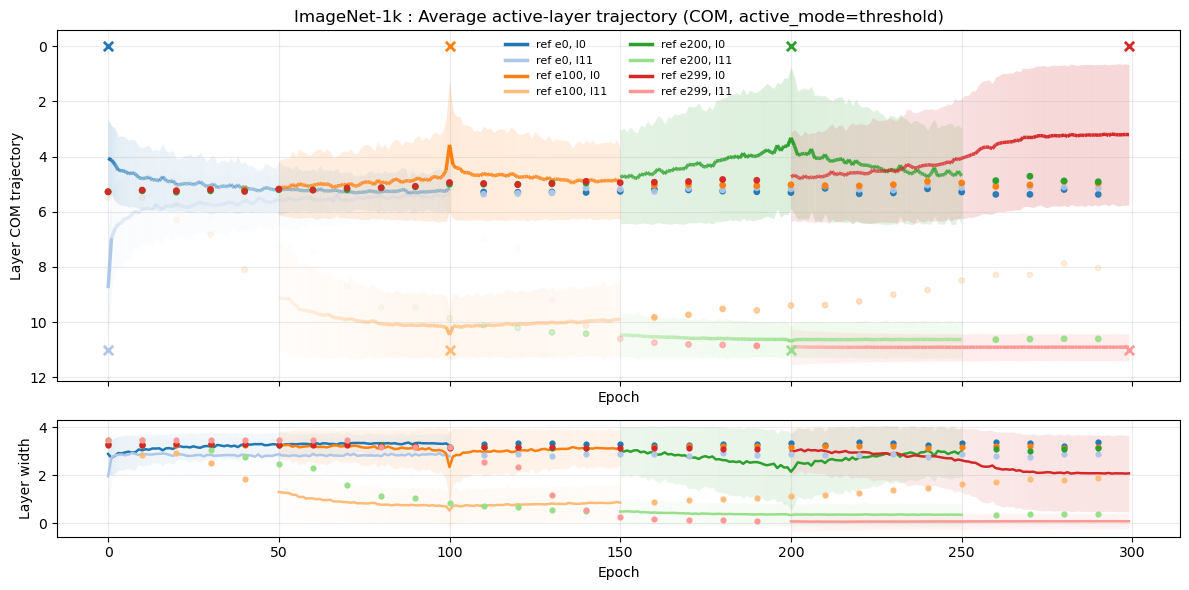

In [6]:
# COM trajectories
seed = "_s8"
tag = "threshold_emergence_com"
fig, axes, results = plot_reference_average_layer_trajectories(
    reference_layers=[0 , 11],
    reference_epochs=[0, 100, 200, 299],
    activation_threshold=None,
    out_file = f"./paper_figs/trajectories_{tag}{seed}.png",
    datapath = "./results/vit_in1k_s8/subset",
    center_method="COM",
    active_mode="threshold",
    onset_k=3,
    disappearance_k=5,
    plot_width=True,
    lowres_as_points=True,
    lowres_step_threshold=1.0,
    min_line_alpha = 0.0,
    lowres_marker_size=15,
    title_tag="ImageNet-1k"
)


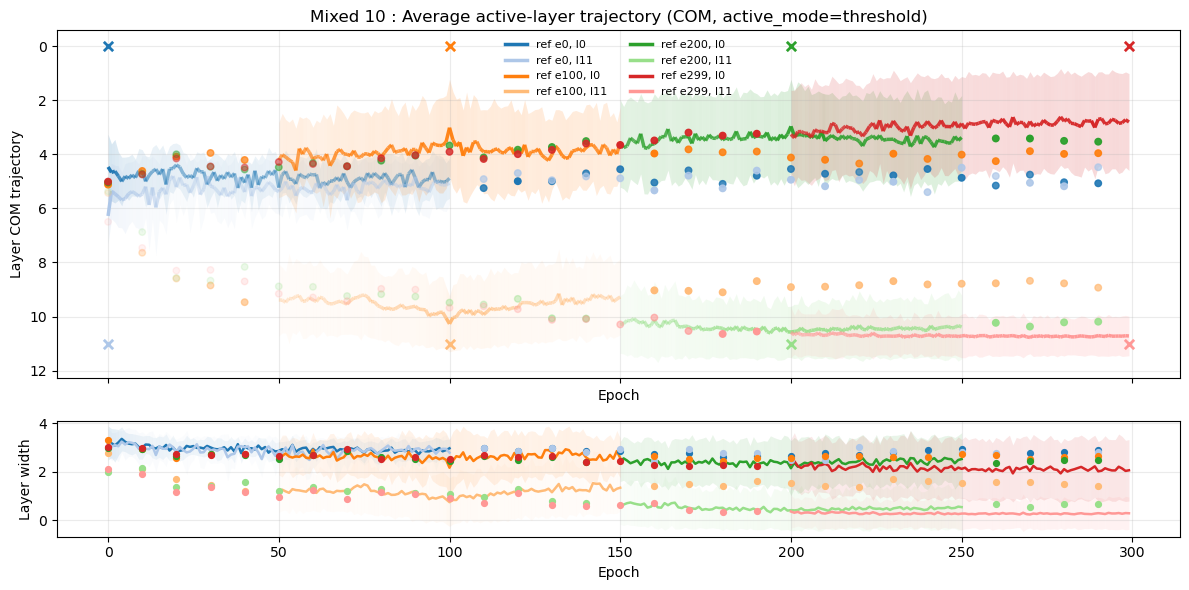

In [7]:
# COM trajectories
seed = "_s7"
tag = "threshold_emergence_com"
fig, axes, results = plot_reference_average_layer_trajectories(
    reference_layers=[0 , 11],
    reference_epochs=[0, 100, 200, 299],
    activation_threshold=None,
    out_file = f"./paper_figs/trajectories_{tag}{seed}.png",
    datapath = "./results/vit_in1k_s8/subset_s7",
    center_method="COM",
    active_mode="threshold",
    onset_k=3,
    disappearance_k=3,
    plot_width=True,
    lowres_as_points=True,
    lowres_step_threshold=1.0,
    title_tag="Mixed 10"
)
